In [16]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
import astropy.units as u
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}

In [2]:
df = pd.read_csv('Dados/results.csv', index_col = 'Cluster')
benchmark_subsample = df[(df.Av<0.5) & (df.dist<1.5)].copy()
data = pd.read_csv('Dados/data.csv', index_col ='Cluster')

In [3]:
df.FeH.describe()

count    771.000000
mean      -0.035634
std        0.107249
min       -0.373000
25%       -0.113500
50%       -0.036000
75%        0.032000
max        0.426000
Name: FeH, dtype: float64

In [4]:
def classificar_metalicidade(m):
    if m < -0:
        return '[Fe/H]<0'
    else:
        return '[Fe/H]>0'
aux = data.copy(deep=True)
aux['FeH_class'] = aux['FeH'].apply(classificar_metalicidade)
df['FeH_class'] = df['FeH'].apply(classificar_metalicidade)

KeyError: 'FeH'

In [ ]:
aux  = aux[aux.q>0]

In [ ]:
aux['FeH_class'].value_counts()

ValueError: Could not interpret value `bin_frac` for `x`. An entry with this name does not appear in `data`.

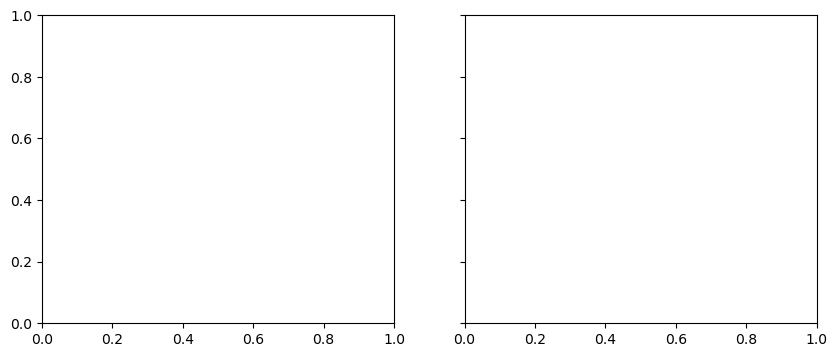

In [6]:
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)


sns.histplot(data=aux, x='bin_frac', hue='FeH_class', bins=12,
                   element='step', fill=None, stat='percent', legend=False, ax=axs[0], hue_order=['[Fe/H]<0', '[Fe/H]>0'])

axs[0].axvline(df[df.FeH<-0.1].bin_frac.median(), color='orange', linestyle='--')
axs[0].axvline(df[df.FeH>=-0.1].bin_frac.median(), color='b', linestyle='--', alpha=0.5)

sns.histplot(data=aux, x='q', hue='FeH_class', bins=12, hue_order=['[Fe/H]<0', '[Fe/H]>0'],
                   element='step', fill=None, stat='percent', legend=False, ax=axs[1])

axs[1].axvline(aux[aux.FeH<-0.1].q.median(), color='gray', linestyle='--')


axs[0].set_xlabel('Binary fraction', fontdict=font)
axs[1].set_xlabel('Mass ratio', fontdict=font)
axs[0].set_ylabel('Percent [%]', fontdict=font)
axs[1].legend(title='', labels=['[Fe/H]<0', '[Fe/H]>0']) 
axs[0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('Figures/hist_mass_ratio_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()

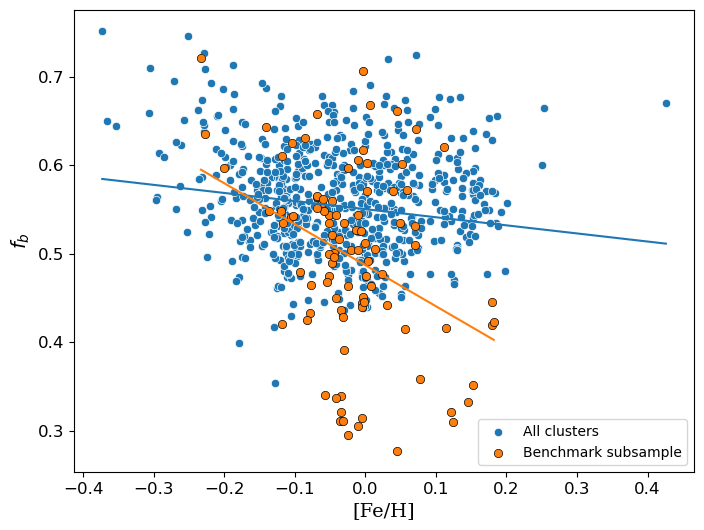

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='FeH', y= 'bin_frac_corr',label='All clusters',)

model1 = LinearRegression()
model1.fit(df[['FeH']], df['bin_frac_corr'])
x_range = np.linspace(df['FeH'].min(), df['FeH'].max(), 200)
y_pred = model1.predict(x_range.reshape(-1,1))

sns.lineplot(x=x_range,y=y_pred)

sns.scatterplot(benchmark_subsample, x='FeH', y= 'bin_frac_corr', label='Benchmark subsample', edgecolor='k')

model2 = LinearRegression()
model2.fit(benchmark_subsample[['FeH']], benchmark_subsample['bin_frac_corr'])
x_range = np.linspace(benchmark_subsample['FeH'].min(), benchmark_subsample['FeH'].max(), 200)
y_pred = model2.predict(x_range.reshape(-1,1))
sns.lineplot(x=x_range,y=y_pred,)


plt.xlabel('[Fe/H]', fontdict=font)
plt.ylabel(r'$f_b$', fontdict=font)
plt.legend(loc='lower right')
plt.tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('Figures/dist_fb_metalicidade.png',bbox_inches='tight', dpi=300)
plt.show()



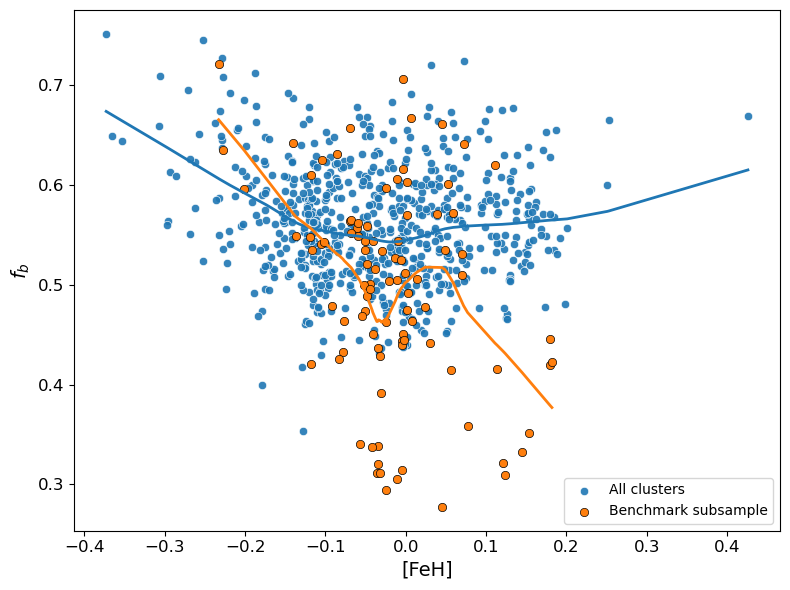

In [92]:
fig, ax = plt.subplots(figsize=(8,6))

sc = sns.scatterplot(data=df, x='FeH', y='bin_frac_corr', legend=False, ax=ax, alpha=0.9, label = 'All clusters')

lowess = sm.nonparametric.lowess
y_smoothed = lowess(df.bin_frac_corr, df.FeH, frac=0.5)
ax.plot(y_smoothed[:,0], y_smoothed[:,1], lw=2 )

sc = sns.scatterplot(data=benchmark_subsample, x='FeH', y='bin_frac_corr', legend=False, ax=ax, edgecolor='k', label = 'Benchmark subsample')

lowess = sm.nonparametric.lowess
y_smoothed = lowess(benchmark_subsample.bin_frac_corr, benchmark_subsample.FeH, frac=0.5)
ax.plot(y_smoothed[:,0], y_smoothed[:,1], lw=2)


ax.set_xlabel('[FeH]', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Figures/dist_fb_metalicidade.png',bbox_inches='tight', dpi=300)
plt.show()
